# 📊  Week 07 — RAG Evaluation & Multi-Objective HPO
### CSAI-415  ·  Special Topics in AI  |  Hands-On Lab

In **Week 05** we built a retrieval pipeline for scientific papers: PDF → chunks → BGE-small embeddings → Qdrant + MongoDB → hybrid search. It runs, but we have no quantitative way to tell whether it is *any good* — and no principled way to choose between the dozen design knobs (chunk size, BM25 parameters, hybrid weighting, reranking, …).

This week we close those gaps.

| § | Section | Implements lecture |
|---|---------|--------------------|
| 1 | **Setup** — re-build the Week 05 retrieval pipeline in this kernel (self-contained) | — |
| 2 | Build an evaluation set with held-out queries | slide 31 (Q, R, L setup) |
| 3 | Implement Recall@k, Precision@k, MRR, NDCG@k from first principles | slides 32–34 |
| 4 | Measure dense / BM25 / hybrid baselines | slides 22, 24, 25 |
| 5 | Add a cross-encoder reranker and quantify the lift | slides 27–29 |
| 6 | Precompute an **index panel** of 5 chunking strategies | slide 14 (the three knobs) |
| 7 | **Multi-objective HPO** with Optuna NSGA-II → Pareto front of (NDCG@10, latency) | callback to the Week 03 HPO module |
| 8 | Pick a winning configuration and report final test scores | — |

The lecture's recurring claim was: *with a strong LLM, RAG quality is bounded by retrieval quality.* By the end of this lab, you will have **measured** how much retrieval quality you can squeeze out of the system from Week 05, and at what latency cost.

> 💡 **This notebook is self-contained.** You do not need to have run Week 05 in the same kernel. Section 1 rebuilds everything it needs. For the full pedagogical walk-through of the pipeline (BibTeX parsing, citation graphs, MongoDB document registry, FastAPI server) refer to the Week 05 notebook.


---
## 1.  Setup — rebuild the Week 05 retrieval pipeline

This section replicates **the retrieval-relevant parts** of Week 05 in a condensed form: PDF text extraction, sliding-window chunking, BGE-small embeddings, Qdrant vector store, BM25 index, and a hybrid search function. The BibTeX/citation-graph/MongoDB layers from Week 05 are not needed for evaluation or HPO, so we omit them here.

Each cell that follows mirrors a Week 05 component with minimal commentary — if anything is unclear, the corresponding Week 05 cell explains the *why* in depth.


In [1]:
!pip install -q \
    pymupdf \
    sentence-transformers \
    qdrant-client \
    rank_bm25 \
    optuna \
    tqdm matplotlib pandas

print("✅ Packages installed")


✅ Packages installed


In [2]:
import os, re, json, time, random, urllib.request, warnings
from pathlib import Path
from typing import Callable, Dict, List, Tuple, Optional
from dataclasses import dataclass, field
from collections import defaultdict

import fitz                                      # PyMuPDF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer, CrossEncoder
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
)
from rank_bm25 import BM25Okapi

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("✅ Imports ready")


✅ Imports ready


### 1.1  Download the sample papers

We use the same two papers as Week 05: Vaswani et al. *Attention Is All You Need* (2017) and Devlin et al. *BERT* (2018). If you already have `./papers/VaswaniSPUJGKP17.pdf` and `./papers/devlin2018bert.pdf` from Week 05, the download is skipped.


In [3]:
PAPERS_DIR = Path("./papers")
PAPERS_DIR.mkdir(exist_ok=True)

PAPERS = {
    "VaswaniSPUJGKP17": "https://arxiv.org/pdf/1706.03762",
    "devlin2018bert":   "https://arxiv.org/pdf/1810.04805",
}

for stem, url in PAPERS.items():
    pdf_path = PAPERS_DIR / f"{stem}.pdf"
    if not pdf_path.exists():
        print(f"⏳ Downloading {stem}…")
        urllib.request.urlretrieve(url, pdf_path)
print("✅ Papers ready:", [p.name for p in PAPERS_DIR.glob("*.pdf")])


✅ Papers ready: ['devlin2018bert.pdf', 'VaswaniSPUJGKP17.pdf']


### 1.2  PDF text extraction & chunking (condensed from Week 05 §5)

`PDFTextExtractor` reads the body text page-by-page using PyMuPDF. `SlidingWindowChunker` produces 400-word chunks with 50-word overlap. Schema matches Week 05: every chunk has `chunk_id`, `doc_id`, `page_num`, `chunk_seq`, `section`, `chunk_type`, `text`, `word_count`.


In [4]:
class PDFTextExtractor:
    """Extracts page text from a PDF. `layout_mode='blocks'` is column-aware."""

    def __init__(self, layout_mode: str = "text", min_chars: int = 50):
        assert layout_mode in ("text", "blocks")
        self.layout_mode = layout_mode
        self.min_chars   = min_chars

    def extract_pages(self, pdf_path: str, doc_id: str) -> List[Dict]:
        doc    = fitz.open(pdf_path)
        source = Path(pdf_path).name
        pages  = []
        for page_num, page in enumerate(doc, start=1):
            text = (self._blocks(page) if self.layout_mode == "blocks"
                                       else page.get_text("text"))
            text = self._clean(text)
            if len(text) < self.min_chars:
                continue
            pages.append({"doc_id": doc_id, "source": source,
                          "page_num": page_num, "text": text,
                          "headings": self._headings(page)})
        doc.close()
        return pages

    def _blocks(self, page) -> str:
        blocks = page.get_text("blocks")
        mid    = page.rect.width / 2
        left   = sorted([b for b in blocks if b[0] < mid],  key=lambda b: b[1])
        right  = sorted([b for b in blocks if b[0] >= mid], key=lambda b: b[1])
        return " ".join(b[4] for b in left + right if b[4].strip())

    def _headings(self, page) -> List[str]:
        heads = []
        for block in page.get_text("dict")["blocks"]:
            if block.get("type") != 0:
                continue
            for line in block.get("lines", []):
                for span in line.get("spans", []):
                    flags, size, text = span.get("flags", 0), span.get("size", 0), span.get("text", "").strip()
                    if text and (bool(flags & 16) or size > 13) and len(text) < 120:
                        heads.append(text)
        return list(dict.fromkeys(heads))

    @staticmethod
    def _clean(t: str) -> str:
        t = re.sub(r"-\n", "", t)
        t = re.sub(r"\n+", " ", t)
        t = re.sub(r"[ \t]{2,}", " ", t)
        return t.strip()


class SlidingWindowChunker:
    """400-word windows, 50-word overlap. Matches Week 05 defaults."""

    def __init__(self, chunk_size: int = 400, overlap: int = 50):
        self.chunk_size, self.overlap = chunk_size, overlap

    def chunk_pages(self, pages: List[Dict]) -> List[Dict]:
        chunks, step = [], self.chunk_size - self.overlap
        for page in pages:
            words = page["text"].split()
            if not words: continue
            section = page["headings"][0] if page["headings"] else "Body"
            for seq, idx in enumerate(range(0, len(words), step)):
                window = words[idx: idx + self.chunk_size]
                if not window: break
                chunks.append({
                    "chunk_id":   f"{page['doc_id']}_p{page['page_num']}_c{seq}",
                    "doc_id":     page["doc_id"],
                    "source":     page["source"],
                    "page_num":   page["page_num"],
                    "chunk_seq":  seq,
                    "section":    section,
                    "chunk_type": "body",
                    "text":       " ".join(window),
                    "word_count": len(window),
                })
        return chunks


# Build chunks from both papers
extractor = PDFTextExtractor(layout_mode="text")
chunker   = SlidingWindowChunker(chunk_size=400, overlap=50)

all_chunks = []
for stem in PAPERS:
    pages = extractor.extract_pages(str(PAPERS_DIR / f"{stem}.pdf"), doc_id=stem)
    all_chunks.extend(chunker.chunk_pages(pages))

chunks_df = pd.DataFrame(all_chunks)
print(f"✅ Built {len(chunks_df)} chunks across {chunks_df['doc_id'].nunique()} papers")
chunks_df.head(3)


✅ Built 61 chunks across 2 papers


,chunk_id,doc_id,source,page_num,chunk_seq,section,chunk_type,text,word_count
0,VaswaniSPUJGKP17_p1_c0,VaswaniSPUJGKP17,VaswaniSPUJGKP17.pdf,1,0,Attention Is All You Need,body,"Provided proper attribution is provided, Googl...",393
1,VaswaniSPUJGKP17_p1_c1,VaswaniSPUJGKP17,VaswaniSPUJGKP17.pdf,1,1,Attention Is All You Need,body,"tensor2tensor, replacing our earlier codebase,...",43
2,VaswaniSPUJGKP17_p2_c0,VaswaniSPUJGKP17,VaswaniSPUJGKP17.pdf,2,0,1,body,"1 Introduction Recurrent neural networks, long...",400


### 1.3  Embeddings — BGE-small (condensed from Week 05 §6)

We use `BAAI/bge-small-en-v1.5` with the BGE query-instruction prefix. Embeddings are L2-normalised so cosine = dot product. Dimension is 384.


In [5]:
class EmbeddingEngine:
    QUERY_PREFIX = "Represent this sentence for searching relevant passages: "

    def __init__(self, model_name: str = "BAAI/bge-small-en-v1.5"):
        print(f"⏳ Loading {model_name}")
        self.model = SentenceTransformer(model_name)
        self.dim   = self.model.get_sentence_embedding_dimension()
        print(f"✅ Loaded | dim={self.dim}")

    def embed_documents(self, texts: List[str], batch_size: int = 32) -> np.ndarray:
        return self.model.encode(texts, batch_size=batch_size,
                                 show_progress_bar=True, normalize_embeddings=True)

    def embed_query(self, query: str) -> np.ndarray:
        return self.model.encode(self.QUERY_PREFIX + query, normalize_embeddings=True)


embedder = EmbeddingEngine()

# Embed every chunk
chunk_vecs = embedder.embed_documents(chunks_df["text"].tolist())
print(f"📐 Embedding matrix: {chunk_vecs.shape}")


⏳ Loading BAAI/bge-small-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Loaded | dim=384


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

📐 Embedding matrix: (61, 384)


### 1.4  Qdrant vector store (condensed from Week 05 §7)


In [6]:
QDRANT_COLLECTION = "scientific_papers"

qdrant = QdrantClient(":memory:")
qdrant.recreate_collection(
    collection_name=QDRANT_COLLECTION,
    vectors_config=VectorParams(size=embedder.dim, distance=Distance.COSINE),
)
qdrant.upload_points(
    collection_name=QDRANT_COLLECTION,
    points=[
        PointStruct(id=i, vector=vec.tolist(),
                    payload={"chunk_id": chunks_df.iloc[i]["chunk_id"]})
        for i, vec in enumerate(chunk_vecs)
    ],
)
print(f"✅ Qdrant collection '{QDRANT_COLLECTION}' ready with {len(chunks_df)} vectors")


✅ Qdrant collection 'scientific_papers' ready with 61 vectors


### 1.5  BM25 index (condensed from Week 05 §10)


In [7]:
def tokenize(text: str) -> List[str]:
    """Lowercase, alphabetic tokens of length ≥ 2 — matches Week 05 BM25Retriever."""
    return re.findall(r"\b[a-z]{2,}\b", text.lower())

bm25_corpus = [tokenize(t) for t in chunks_df["text"]]
bm25        = BM25Okapi(bm25_corpus)
print(f"✅ BM25 index built over {len(bm25_corpus)} chunks")


✅ BM25 index built over 61 chunks


### 1.6  Retrieval functions

`search_dense`, `search_bm25`, and `search_hybrid` (RRF) take a query string and a `k`, return a list of `chunk_id`s ranked by relevance. These three functions are what every downstream section evaluates and tunes.


In [8]:
# Quick lookup from chunk_id to row index — needed for BM25 result resolution
_id_to_idx = {cid: i for i, cid in enumerate(chunks_df["chunk_id"])}


def search_dense(query: str, k: int = 10) -> List[str]:
    qvec = embedder.embed_query(query).tolist()
    hits = qdrant.query_points(
        collection_name=QDRANT_COLLECTION,
        query=qvec, limit=k, with_payload=True,
    ).points
    return [h.payload["chunk_id"] for h in hits]


def search_bm25(query: str, k: int = 10) -> List[str]:
    scores  = bm25.get_scores(tokenize(query))
    top_idx = np.argsort(scores)[::-1][:k]
    return [chunks_df.iloc[i]["chunk_id"] for i in top_idx if scores[i] > 0]


def search_hybrid(query: str, k: int = 10, rrf_k: int = 60,
                  candidate_k: Optional[int] = None) -> List[str]:
    """
    Hybrid retrieval via Reciprocal Rank Fusion. Default to fusing top
    2*k from each retriever — matches Week 05's pattern.
    """
    ck = candidate_k if candidate_k is not None else 2 * k
    dense_ids  = search_dense(query, k=ck)
    sparse_ids = search_bm25(query, k=ck)
    rrf = defaultdict(float)
    for r, cid in enumerate(dense_ids,  start=1): rrf[cid] += 1.0 / (rrf_k + r)
    for r, cid in enumerate(sparse_ids, start=1): rrf[cid] += 1.0 / (rrf_k + r)
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


# Smoke test
print("Dense top-3 :", search_dense("multi-head attention", k=3))
print("BM25 top-3  :", search_bm25 ("multi-head attention", k=3))
print("Hybrid top-3:", search_hybrid("multi-head attention", k=3))


Dense top-3 : ['VaswaniSPUJGKP17_p5_c0', 'VaswaniSPUJGKP17_p4_c0', 'VaswaniSPUJGKP17_p13_c0']
BM25 top-3  : ['VaswaniSPUJGKP17_p5_c0', 'VaswaniSPUJGKP17_p4_c0', 'VaswaniSPUJGKP17_p3_c0']
Hybrid top-3: ['VaswaniSPUJGKP17_p5_c0', 'VaswaniSPUJGKP17_p4_c0', 'VaswaniSPUJGKP17_p2_c1']


### 1.7  Setup checklist

At this point in the kernel we have:

| Symbol | Description |
|--------|-------------|
| `chunks_df` | DataFrame of every chunk with text + metadata |
| `embedder` | The BGE-small encoder (`embed_documents`, `embed_query`) |
| `qdrant` | Qdrant client with the `scientific_papers` collection |
| `bm25` | The BM25 sparse index over `chunks_df` |
| `search_dense`, `search_bm25`, `search_hybrid` | Retrieval functions returning ranked `chunk_id` lists |

Everything below assumes only these. We are now ready for the evaluation work.


---
## 2.  Loading the evaluation set

> *Lecture slide 31 — we need three ingredients: a set of queries Q, a ground-truth relevant set R per query, and a returned list L from the retriever.*

For a teaching lab we want labelled (query, relevant-chunk) pairs ready to go — without each student burning LLM tokens or hand-labelling. This notebook ships with a pre-built `eval_set.json`:

- **30 queries** split evenly between the two papers (Attention Is All You Need + BERT)
- Each query targets a single chunk that should ideally appear at rank 1
- Researcher-style phrasings — *"How many attention heads does the base Transformer model use?"*, *"What is the purpose of next sentence prediction?"*, etc.

Some caveats worth noting in class:

| Caveat | What it means for results |
|--------|--------------------------|
| **Single-gold per query.** | NDCG@10 above ~0.8 is realistic, but Recall@10 is binary per query (0 or 1) — slightly noisier than benchmarks with multi-gold labels. |
| **The corpus has only 2 papers.** | Retrieval is "easy" by benchmark standards — a real corpus would have 10⁴–10⁶ chunks and the metric numbers would drop. Don't compare absolute scores to MS MARCO / BEIR. |
| **Same-author bias.** | Some queries are phrased close to how the paper itself describes the concept. This makes dense retrieval look slightly better than it would on naturally-phrased user queries. |

The bias caveats matter for *absolute* scores but not for the *relative ranking* of retrieval configurations — which is what HPO will use the eval set for.


### 2.1  Load the pre-built eval set (with auto-repair)

A pre-built `eval_set.json` ships with this notebook — 30 hand-crafted queries split evenly across the two papers, targeting key technical concepts (scaled dot-product attention, BERT's MLM objective, training hyperparameters, etc.). Each entry has:

- `query` — the researcher-style question
- `relevant_chunk_ids` — best-guess gold chunk IDs (e.g. `VaswaniSPUJGKP17_p4_c0`)
- `source_chunk_text` — a ~70-word snippet of the target chunk's content

**Auto-repair.** The gold chunk IDs were authored against the paper structure, but the actual `c{seq}` suffix the chunker assigns depends on the exact word counts after PyMuPDF extraction. Different layout modes or chunk sizes could shift things. So at load time we *verify* each gold ID exists in `chunks_df`; for any that don't, we re-resolve the gold chunk by finding the chunk whose text has the highest word-overlap with `source_chunk_text`. This makes the eval set portable to any chunking config.


In [9]:
EVAL_PATH = Path("eval_set.json")


def _word_overlap(a: str, b: str) -> float:
    """Fraction of distinctive words from `a` that also appear in `b`."""
    aw = set(re.findall(r"[a-z]{3,}", a.lower()))
    bw = set(re.findall(r"[a-z]{3,}", b.lower()))
    if not aw: return 0.0
    return len(aw & bw) / len(aw)


def repair_eval_set(eval_set: list, chunks_df: pd.DataFrame) -> list:
    """
    For every entry whose declared relevant_chunk_ids are not all present in
    chunks_df, re-resolve the gold chunk by maximum word-overlap with
    source_chunk_text. Returns the repaired eval_set.
    """
    valid_ids = set(chunks_df["chunk_id"])
    repaired, n_repaired = [], 0

    for q in eval_set:
        gold = q.get("relevant_chunk_ids", [])
        if gold and all(g in valid_ids for g in gold):
            repaired.append(q)
            continue

        # Repair: rank chunks_df by overlap with the snippet
        snippet = q.get("source_chunk_text", "")
        if not snippet:
            print(f"  ⚠ skipping un-repairable query (no snippet): {q['query'][:60]}")
            continue
        scores = chunks_df["text"].apply(lambda t: _word_overlap(snippet, t))
        best   = chunks_df.iloc[scores.idxmax()]["chunk_id"]
        q_new  = dict(q)
        q_new["relevant_chunk_ids"] = [best]
        q_new["_repaired_from"]     = gold
        repaired.append(q_new)
        n_repaired += 1

    if n_repaired:
        print(f"🔧 Auto-repaired {n_repaired}/{len(eval_set)} queries "
              "(chunk_ids resolved via snippet matching).")
    else:
        print(f"✓ All {len(eval_set)} gold chunk_ids verified — no repair needed.")
    return repaired


if not EVAL_PATH.exists():
    raise FileNotFoundError(
        f"{EVAL_PATH} not found. The pre-built eval_set.json should ship with "
        "this notebook — place it in the same directory."
    )

eval_set_raw = json.loads(EVAL_PATH.read_text())
eval_set     = repair_eval_set(eval_set_raw, chunks_df)
print(f"\n✓ Loaded {len(eval_set)} queries.")

# Preview
for ex in eval_set[:3]:
    print(f"\n  Q: {ex['query']}\n     → {ex['relevant_chunk_ids']}")


✓ All 30 gold chunk_ids verified — no repair needed.

✓ Loaded 30 queries.

  Q: What is the formula for scaled dot-product attention?
     → ['VaswaniSPUJGKP17_p4_c0']

  Q: How many attention heads does the base Transformer model use?
     → ['VaswaniSPUJGKP17_p5_c0']

  Q: Why does the Transformer use sinusoidal positional encodings?
     → ['VaswaniSPUJGKP17_p6_c0']


### Train / test split on queries

We split the queries — **not** the corpus — into a train set (used by HPO to score trials) and a test set (held out for final reporting).

Why split on queries? Because HPO will try many configurations and pick whichever one scores best on the train queries. If we then *report* test scores on those same queries, we have overfit to them and the numbers are optimistic. Holding out a test query set gives an honest final number.

20 train / 10 test is a tight split. In a real lab you would use 100+ queries. Thirty is what fits a class budget; it is enough to *demonstrate* the methodology, not enough to make production-grade claims.


In [10]:
rng = random.Random(SEED)
shuffled = eval_set[:]
rng.shuffle(shuffled)

train_queries = shuffled[:20]
test_queries  = shuffled[20:30]

print(f"Train: {len(train_queries)} queries  |  Test: {len(test_queries)} queries")


Train: 20 queries  |  Test: 10 queries


---
## 3.  Implementing the four metrics

> *Lecture slides 32–34. Recall@k, Precision@k, RR/MRR, NDCG@k.*

We code each metric in the simplest possible form. The signature is uniform: each takes a **ranked list of chunk ids** and a **set of gold-relevant chunk ids**, returning a float in [0, 1]. This signature lets us evaluate any retriever uniformly.


In [11]:
def recall_at_k(ranked: List[str], gold: List[str], k: int) -> float:
    if not gold: return 0.0
    top = set(ranked[:k])
    return sum(1 for g in gold if g in top) / len(gold)

def precision_at_k(ranked: List[str], gold: List[str], k: int) -> float:
    if k == 0: return 0.0
    top = ranked[:k]
    return sum(1 for c in top if c in gold) / k

def reciprocal_rank(ranked: List[str], gold: List[str], k: int) -> float:
    gold_set = set(gold)
    for i, c in enumerate(ranked[:k], start=1):
        if c in gold_set:
            return 1.0 / i
    return 0.0

def dcg_at_k(ranked: List[str], gold: List[str], k: int) -> float:
    gold_set = set(gold)
    return sum((1.0 if c in gold_set else 0.0) / np.log2(i + 1)
               for i, c in enumerate(ranked[:k], start=1))

def ndcg_at_k(ranked: List[str], gold: List[str], k: int) -> float:
    n_relevant_in_top_k = min(len(gold), k)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, n_relevant_in_top_k + 1))
    if idcg == 0: return 0.0
    return dcg_at_k(ranked, gold, k) / idcg


### Sanity check against the lecture's worked example

In the lecture (slides 35–36) we computed metrics for the ranking `rel = [0, 1, 0, 1]` with 2 relevant chunks total. Expected:

- Recall@4 = **1.00**, Precision@4 = **0.50**, RR = **0.50**
- DCG@4 ≈ 1.061,  IDCG@4 ≈ 1.631,  **NDCG@4 ≈ 0.651**

We verify our implementations reproduce these exactly.


In [12]:
# Reconstruct the lecture example: 4 chunks returned, c2 and c4 are relevant.
ranked = ["c1", "c2", "c3", "c4"]
gold   = ["c2", "c4"]

print(f"Recall@4    = {recall_at_k(ranked, gold, 4):.3f}   (expected 1.000)")
print(f"Precision@4 = {precision_at_k(ranked, gold, 4):.3f}   (expected 0.500)")
print(f"RR          = {reciprocal_rank(ranked, gold, 4):.3f}   (expected 0.500)")
print(f"DCG@4       = {dcg_at_k(ranked, gold, 4):.3f}   (expected ≈ 1.061)")
print(f"NDCG@4      = {ndcg_at_k(ranked, gold, 4):.3f}   (expected ≈ 0.651)")

assert abs(ndcg_at_k(ranked, gold, 4) - 0.651) < 0.01, "NDCG implementation broken!"
print("\n✓ Matches the lecture.")


Recall@4    = 1.000   (expected 1.000)
Precision@4 = 0.500   (expected 0.500)
RR          = 0.500   (expected 0.500)
DCG@4       = 1.062   (expected ≈ 1.061)
NDCG@4      = 0.651   (expected ≈ 0.651)

✓ Matches the lecture.


### Per-query and per-retriever helpers

We will evaluate each retriever over many queries — let's package the metric set into a single function that returns a dictionary, and a query-set evaluator that averages over queries.


In [13]:
def evaluate_query(ranked: List[str], gold: List[str], k: int = 10) -> Dict[str, float]:
    return {
        f"recall@{k}":     recall_at_k(ranked, gold, k),
        f"precision@{k}":  precision_at_k(ranked, gold, k),
        f"rr@{k}":         reciprocal_rank(ranked, gold, k),
        f"ndcg@{k}":       ndcg_at_k(ranked, gold, k),
    }

def evaluate_retriever(retrieve_fn: Callable[[str, int], List[str]],
                       queries: List[dict],
                       k: int = 10) -> Dict[str, float]:
    """
    retrieve_fn(query_str, k) -> list of chunk_ids ranked by relevance.
    Returns metric averages across queries.
    """
    per_q = [evaluate_query(retrieve_fn(q["query"], k),
                            q["relevant_chunk_ids"], k=k)
             for q in queries]
    return {m: float(np.mean([p[m] for p in per_q])) for m in per_q[0]}


---
## 4.  Baseline measurements: dense vs BM25 vs hybrid

Before we add complexity (reranker, HPO), we measure what Week 05 actually produced. Each retriever below is a one-line wrapper over the §1 primitives — but the metric numbers tell the story.

We report on the **train** split for now. Test is held out for the final comparison at the very end.


In [14]:
results = {}
for name, fn in [("dense", search_dense), ("bm25", search_bm25),
                 ("hybrid", search_hybrid)]:
    results[name] = evaluate_retriever(fn, train_queries, k=10)

baseline_df = pd.DataFrame(results).T.round(3)
baseline_df.index.name = "retriever"
baseline_df


,recall@10,precision@10,rr@10,ndcg@10
retriever,,,,
dense,0.80,0.080,0.320,0.434
bm25,0.35,0.035,0.153,0.202
hybrid,0.60,0.060,0.263,0.342


### What to look for in the table

The lecture predicted: *semantic and lexical are complementary; hybrid usually wins.* If that pattern holds in your numbers — hybrid leading on NDCG@10 even if dense or BM25 wins on Recall@10 — your system behaves the way the literature says it should.

If hybrid does *not* win, that is a useful signal: it usually means the BM25 weight is set incorrectly, or your queries skew strongly to one mode (very paraphrased → favours dense, lots of exact strings → favours BM25). HPO in §7 will tune that weight automatically.


---
## 5.  Adding a cross-encoder reranker

> *Lecture slides 27–29. Bi-encoder for scale, cross-encoder for accuracy.*

Hybrid retrieval gives us a ranked list, but the ranking is coarse — cosine and BM25 each look at query and chunk independently. A **cross-encoder** scores `(query, chunk)` *jointly* through a transformer with full attention, producing a much sharper relevance score. The price is that each `(query, chunk)` pair is a separate forward pass — we cannot precompute.

The standard pattern: retrieve a wide candidate set with hybrid (say k=100), rerank with a cross-encoder, keep the top-N (say 10). We use `cross-encoder/ms-marco-MiniLM-L-6-v2` — small, fast, well-trained on retrieval data.


In [15]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", max_length=512)

# Cache chunk text by id for fast lookup during reranking
_chunk_text = dict(zip(chunks_df["chunk_id"], chunks_df["text"]))


def rerank(query: str, candidate_ids: List[str], top_n: int = 10) -> List[str]:
    pairs  = [(query, _chunk_text[c]) for c in candidate_ids]
    scores = reranker.predict(pairs, show_progress_bar=False)
    order  = np.argsort(scores)[::-1][:top_n]
    return [candidate_ids[i] for i in order]


def search_hybrid_rerank(query: str, k: int = 10,
                         candidate_k: int = 100) -> List[str]:
    cands = search_hybrid(query, k=candidate_k)
    return rerank(query, cands, top_n=k)


def search_dense_rerank(query: str, k: int = 10,
                        candidate_k: int = 100) -> List[str]:
    cands = search_dense(query, k=candidate_k)
    return rerank(query, cands, top_n=k)


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [16]:
results["dense+rerank"]  = evaluate_retriever(search_dense_rerank,  train_queries, k=10)
results["hybrid+rerank"] = evaluate_retriever(search_hybrid_rerank, train_queries, k=10)

rerank_df = pd.DataFrame(results).T.round(3)
rerank_df.index.name = "retriever"
rerank_df


,recall@10,precision@10,rr@10,ndcg@10
retriever,,,,
dense,0.80,0.080,0.320,0.434
bm25,0.35,0.035,0.153,0.202
hybrid,0.60,0.060,0.263,0.342
dense+rerank,0.55,0.055,0.270,0.336
hybrid+rerank,0.55,0.055,0.270,0.336


### Reading the rerank rows

The reranker should lift NDCG@10 noticeably over both dense and hybrid alone. If it does **not**, two diagnoses are common:

1. **The candidate set is too small.** If hybrid retrieves only 10 candidates and we rerank to 10, the reranker has no room to *re-order* — the relevant chunks were either already in the top 10 or not in the set at all. Try `candidate_k=100`.
2. **The reranker has not seen content like yours.** ms-marco was trained on web-search queries; for legal or biomedical text, a domain-tuned cross-encoder (e.g. `BAAI/bge-reranker-base`) usually outperforms it.

Note Recall@10 typically does **not** improve with reranking — same candidates, just reordered. The reranker's contribution shows up in NDCG and precision.


---
## 6.  Building the index panel

> *Lecture slide 14: chunk size, overlap, embedding dimension — three knobs.*

HPO needs to try different chunking strategies — but re-chunking and re-embedding the corpus inside every HPO trial would be ruinous (minutes per trial × 100 trials = hours). The fix is to **precompute** a panel of indices up front, one per chunking strategy, and let HPO pick among them as a *categorical* hyperparameter. Every trial then stays cheap.

We build 5 variants. The first three vary chunk size and overlap (the lecture's primary knobs); the last two test qualitatively different strategies.

| Variant | Strategy | Chunk size | Overlap |
|---------|----------|------------|---------|
| `naive_256_32`   | fixed word window | 256 | 32  |
| `naive_400_50`   | fixed word window (Week 05 default) | 400 | 50  |
| `naive_1024_128` | fixed word window | 1024 | 128 |
| `sentence_5_1`   | 5 sentences per chunk, 1-sentence overlap | ~varies | — |
| `section_grouped`| chunks grouped by detected section heading  | ~varies | — |

**Note for an extension:** Contextual Retrieval (lecture slide 17) — prepending an LLM-generated context line to each chunk before embedding — could be added as a sixth variant. It is excluded here because it requires an LLM call per chunk; if you have the API budget, the function template is one of the lab's suggested extensions.


In [17]:
@dataclass
class IndexVariant:
    name: str
    chunks: pd.DataFrame      # one row per chunk in this variant
    qdrant: QdrantClient      # vectors under collection name = self.name
    bm25: BM25Okapi
    chunk_text: Dict[str, str] = field(default_factory=dict)


# --- Chunking strategies ---

def chunk_fixed(text: str, size: int, overlap: int) -> List[str]:
    words = text.split()
    if not words: return []
    step = max(1, size - overlap)
    return [" ".join(words[i:i + size]) for i in range(0, len(words), step)
            if words[i:i + size]]

def chunk_by_sentences(text: str, sents_per_chunk: int = 5,
                       overlap_sents: int = 1) -> List[str]:
    sents = re.split(r'(?<=[.!?])\s+', text)
    step  = max(1, sents_per_chunk - overlap_sents)
    return [" ".join(sents[i:i + sents_per_chunk])
            for i in range(0, len(sents), step) if sents[i:i + sents_per_chunk]]


In [18]:
def build_variant(name: str, doc_chunks: List[Tuple[str, str]]) -> IndexVariant:
    """
    doc_chunks: list of (doc_id, chunk_text) tuples for this variant.
    Builds a Qdrant collection + BM25 index. Returns an IndexVariant.
    """
    rows = [{"chunk_id": f"{name}::{i:05d}",
             "doc_id":   doc_id, "text": text}
            for i, (doc_id, text) in enumerate(doc_chunks)]
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No chunks produced for variant {name}.")

    # Embed (re-using the same BGE-small embedder for all variants)
    vecs = embedder.embed_documents(df["text"].tolist())

    # Qdrant collection per variant
    client = QdrantClient(":memory:")
    client.recreate_collection(
        collection_name=name,
        vectors_config=VectorParams(size=vecs.shape[1], distance=Distance.COSINE),
    )
    client.upload_points(
        collection_name=name,
        points=[PointStruct(id=i, vector=v.tolist(),
                            payload={"chunk_id": cid})
                for i, (v, cid) in enumerate(zip(vecs, df["chunk_id"]))],
    )

    # BM25
    bm = BM25Okapi([tokenize(t) for t in df["text"]])

    return IndexVariant(name=name, chunks=df, qdrant=client, bm25=bm,
                        chunk_text=dict(zip(df["chunk_id"], df["text"])))


In [19]:
# Reconstruct per-document raw text from chunks_df (already extracted in §1).
docs = (chunks_df.groupby("doc_id")["text"]
                 .apply(lambda s: " ".join(s)).to_dict())

variants_spec = [
    ("naive_256_32",    lambda t: chunk_fixed(t, 256, 32)),
    ("naive_400_50",    lambda t: chunk_fixed(t, 400, 50)),
    ("naive_1024_128",  lambda t: chunk_fixed(t, 1024, 128)),
    ("sentence_5_1",    lambda t: chunk_by_sentences(t, 5, 1)),
    # section_grouped: group Week 05 chunks by (doc_id, section). For corpora
    # where heading detection failed, this degrades gracefully to "Body" → one chunk per doc.
    ("section_grouped", None),
]

variants: Dict[str, IndexVariant] = {}
for name, chunker_fn in tqdm(variants_spec, desc="Building index panel"):
    if name == "section_grouped":
        grouped = (chunks_df.groupby(["doc_id", "section"])["text"]
                            .apply(" ".join).reset_index())
        corpus = list(zip(grouped["doc_id"], grouped["text"]))
    else:
        corpus = [(d, c) for d, text in docs.items() for c in chunker_fn(text)]
    variants[name] = build_variant(name, corpus)

# Summary
summary = pd.DataFrame([{
    "variant":     v.name,
    "n_chunks":    len(v.chunks),
    "mean_words":  int(v.chunks["text"].str.split().str.len().mean()),
} for v in variants.values()])
summary


Building index panel:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,variant,n_chunks,mean_words
0,naive_256_32,78,253
1,naive_400_50,50,394
2,naive_1024_128,20,980
3,sentence_5_1,277,78
4,section_grouped,28,618


In [25]:
def resolve_gold_in_variant(snippet, variant):
    scores = variant.chunks["text"].apply(lambda t: _word_overlap(snippet, t))
    return variant.chunks.iloc[scores.idxmax()]["chunk_id"]

# Per-variant gold mappings (re-resolves snippet → best chunk in each variant's namespace)
variant_gold_train = {
    vn: [resolve_gold_in_variant(q["source_chunk_text"], v) for q in train_queries]
    for vn, v in variants.items()
}
variant_gold_test = {
    vn: [resolve_gold_in_variant(q["source_chunk_text"], v) for q in test_queries]
    for vn, v in variants.items()
}
print("✓ Per-variant gold mappings built")

✓ Per-variant gold mappings built


---
## 7.  Multi-objective HPO with Optuna NSGA-II

> *Callback to **Week 03** — the HPO module. We are now using HPO **on RAG** — closing the loop between the data-engineering arc and the retrieval arc.*

### Why multi-objective?

The lecture's design tradeoffs were always paired: bi-encoder is *cheap and good*, cross-encoder is *expensive and better*. In production you do not just want the best NDCG — you want the best NDCG **at a tolerable latency**. A configuration that scores 0.85 NDCG by reranking 1000 candidates and taking 4 seconds per query is unusable.

So we frame HPO as multi-objective:

- **Maximize**  NDCG@10 on the train queries
- **Minimize**  median per-query latency

The optimizer returns a **Pareto front** — the set of configurations such that no other configuration is strictly better on both objectives. You (the instructor / production owner) pick a point on the front based on the production constraints.

### Why NSGA-II?

NSGA-II is the standard multi-objective sampler in Optuna (and in the evolutionary-algorithms literature broadly). It maintains a *population* of candidate configurations, evolves them across *generations*, and at each step keeps the ones that dominate others on the (NDCG, latency) plane. It handles mixed categorical / continuous / conditional search spaces well — which is exactly what we have.

### Why these trial / population numbers?

NSGA-II spends one full population per generation. With `population_size=20` and `n_trials=100` we get 5 generations. That is a deliberate teaching budget: enough to see a Pareto front emerge, small enough to finish inside one lab session (~10–15 minutes). A production HPO run would use 500+ trials.


### The search space

We define the search space inside the objective function — this lets some parameters be **conditional** (e.g. `rrf_k` only matters when `combiner="rrf"`). Optuna handles conditional parameters cleanly.

| Hyperparameter | Type | Range |
|----------------|------|-------|
| `index_variant`     | categorical | one of the 5 panel variants |
| `combiner`          | categorical | `"rrf"` or `"weighted"` |
| `alpha`             | continuous (if weighted) | [0.0, 1.0] |
| `rrf_k`             | continuous (if rrf)     | [10, 200] |
| `bm25_k1`           | continuous | [1.0, 2.5] |
| `bm25_b`            | continuous | [0.0, 1.0] |
| `candidate_k`       | integer | [20, 200] |
| `use_reranker`      | categorical | True / False |
| `final_k` (= eval k) | fixed at 10 | — |

`bm25_k1` and `bm25_b` are tuned by re-instantiating BM25 with new parameters; the corpus tokens stay the same so this is cheap.


In [27]:
# Search-space-aware retrieval. Each trial calls this with a config dict.

def search_with_config(query: str, cfg: dict, variant: IndexVariant) -> List[str]:
    cand_k  = cfg["candidate_k"]
    k_final = cfg["final_k"]

    # Dense candidates
    qvec = embedder.embed_query(query).tolist()
    dense_hits = variant.qdrant.query_points(
        collection_name=variant.name, query=qvec, limit=cand_k, with_payload=True,
    ).points
    dense_ids    = [h.payload["chunk_id"] for h in dense_hits]
    dense_scores = {h.payload["chunk_id"]: h.score for h in dense_hits}

    # BM25 with the trial's k1, b
    bm = BM25Okapi([tokenize(t) for t in variant.chunks["text"]],
                   k1=cfg["bm25_k1"], b=cfg["bm25_b"])
    bm_score_arr = bm.get_scores(tokenize(query))
    bm_top = np.argsort(bm_score_arr)[::-1][:cand_k]
    bm_ids = [variant.chunks.iloc[i]["chunk_id"] for i in bm_top]
    bm_scores = {variant.chunks.iloc[i]["chunk_id"]: float(bm_score_arr[i])
                 for i in bm_top}

    # Combine
    if cfg["combiner"] == "rrf":
        rrf_k = cfg["rrf_k"]
        scores = defaultdict(float)
        for r, c in enumerate(dense_ids, 1): scores[c] += 1.0 / (rrf_k + r)
        for r, c in enumerate(bm_ids,    1): scores[c] += 1.0 / (rrf_k + r)
    else:  # weighted
        a = cfg["alpha"]
        # Min-max normalise each score list before weighting
        def norm(d):
            if not d: return {}
            vs = list(d.values()); lo, hi = min(vs), max(vs)
            return {k: (v - lo) / (hi - lo) if hi > lo else 0.0
                    for k, v in d.items()}
        dn, bn = norm(dense_scores), norm(bm_scores)
        scores = defaultdict(float)
        for c, v in dn.items(): scores[c] += a * v
        for c, v in bn.items(): scores[c] += (1 - a) * v

    fused = sorted(scores, key=scores.get, reverse=True)[:cand_k]

    # Optional rerank
    if cfg["use_reranker"]:
        pairs = [(query, variant.chunk_text[c]) for c in fused]
        ce_scores = reranker.predict(pairs, show_progress_bar=False)
        fused = [fused[i] for i in np.argsort(ce_scores)[::-1]]

    return fused[:k_final]


### Latency measurement protocol

Each trial measures latency over the train queries. We use:

1. **Warmup** — discard the first query's time (model weights load on first call; Qdrant cold-cache effects).
2. **Median of 3 runs per query** — robust to single-call outliers.
3. **Median across queries** — robust to one query being particularly hard/easy.

This is deliberate. Without warmup, the first trial of any HPO run looks artificially slow and biases the optimizer away from configurations that happened to come first.


In [28]:
def time_one_query(query: str, cfg: dict, variant: IndexVariant,
                    n_runs: int = 3) -> float:
    times = []
    for _ in range(n_runs):
        t = time.perf_counter()
        _ = search_with_config(query, cfg, variant)
        times.append(time.perf_counter() - t)
    return float(np.median(times))


# def score_config(cfg: dict, queries: List[dict]) -> Tuple[float, float]:
#     """Returns (mean_ndcg@10, median_latency_seconds) over the queries."""
#     variant = variants[cfg["index_variant"]]

#     # Warmup — discard
#     _ = time_one_query(queries[0]["query"], cfg, variant, n_runs=1)

#     ndcgs, lats = [], []
#     for q in queries:
#         ranked = search_with_config(q["query"], cfg, variant)
#         ndcgs.append(ndcg_at_k(ranked, q["relevant_chunk_ids"], k=cfg["final_k"]))
#         lats.append(time_one_query(q["query"], cfg, variant, n_runs=3))

#     return float(np.mean(ndcgs)), float(np.median(lats))

def score_config(cfg, queries, variant_gold_map):
    variant = variants[cfg["index_variant"]]
    gold_list = variant_gold_map[cfg["index_variant"]]
    _ = time_one_query(queries[0]["query"], cfg, variant, n_runs=1)
    ndcgs, lats = [], []
    for q, gold in zip(queries, gold_list):
        ranked = search_with_config(q["query"], cfg, variant)
        ndcgs.append(ndcg_at_k(ranked, [gold], k=cfg["final_k"]))
        lats.append(time_one_query(q["query"], cfg, variant, n_runs=1))
    return float(np.mean(ndcgs)), float(np.median(lats))


In [29]:
import optuna
from optuna.samplers import NSGAIISampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial: optuna.Trial) -> Tuple[float, float]:
    cfg = {
        "index_variant": trial.suggest_categorical(
            "index_variant", list(variants.keys())),
        "combiner":      trial.suggest_categorical("combiner", ["rrf", "weighted"]),
        "bm25_k1":       trial.suggest_float("bm25_k1", 1.0, 2.5),
        "bm25_b":        trial.suggest_float("bm25_b",  0.0, 1.0),
        "candidate_k":   trial.suggest_int  ("candidate_k", 20, 200, step=10),
        "use_reranker":  trial.suggest_categorical("use_reranker", [True, False]),
        "final_k":       10,
    }
    if cfg["combiner"] == "rrf":
        cfg["rrf_k"] = trial.suggest_float("rrf_k", 10.0, 200.0)
    else:
        cfg["alpha"] = trial.suggest_float("alpha", 0.0, 1.0)

    ndcg, latency = score_config(cfg, train_queries, variant_gold_train)
    return ndcg, latency  # maximize, minimize


study = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=NSGAIISampler(population_size=20, seed=SEED),
)

N_TRIALS = 100
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✓ Done. {len(study.best_trials)} trials on the Pareto front.")


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Done. 3 trials on the Pareto front.


### Pareto front

Each dot is a configuration HPO tried. Dots on the front (top-left edge) are *Pareto-optimal* — no other config dominates them on both axes simultaneously.


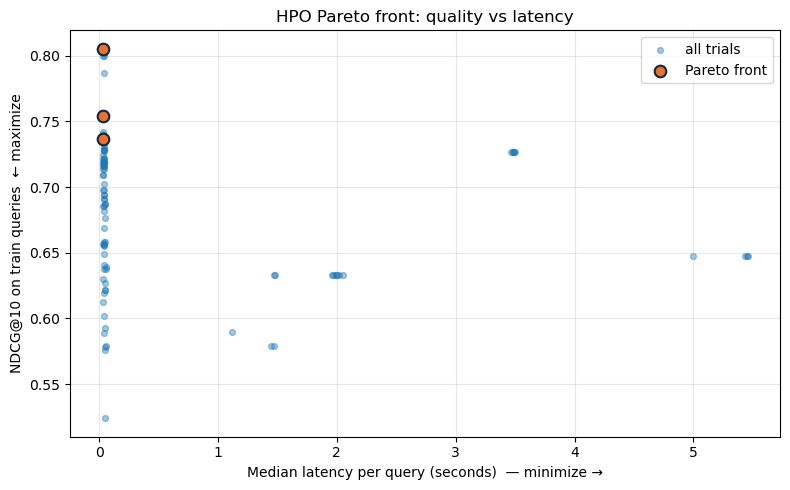

In [30]:
xs = [t.values[1] for t in study.trials if t.values is not None]
ys = [t.values[0] for t in study.trials if t.values is not None]
pf_xs = [t.values[1] for t in study.best_trials]
pf_ys = [t.values[0] for t in study.best_trials]

plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=18, alpha=0.4, label="all trials")
plt.scatter(pf_xs, pf_ys, s=70, edgecolor="#0E2841",
            facecolor="#E97132", linewidth=1.5, label="Pareto front", zorder=3)
plt.xlabel("Median latency per query (seconds)  — minimize →")
plt.ylabel("NDCG@10 on train queries  ← maximize")
plt.title("HPO Pareto front: quality vs latency")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


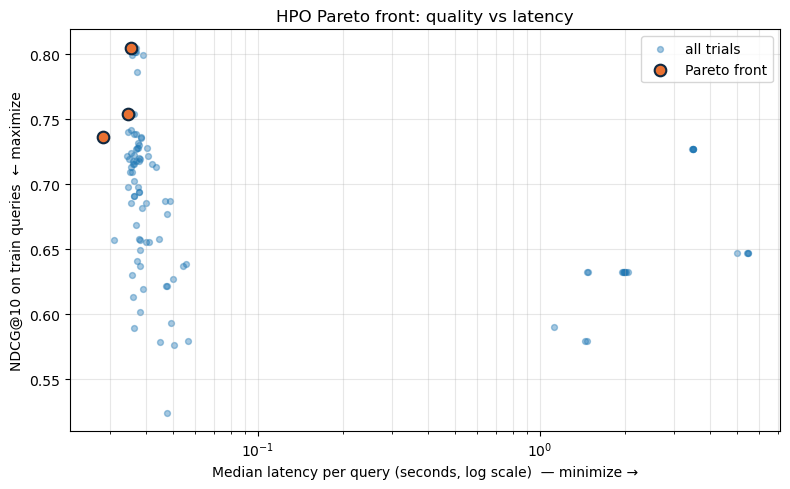

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=18, alpha=0.4, label="all trials")
plt.scatter(pf_xs, pf_ys, s=70, edgecolor="#0E2841",
            facecolor="#E97132", linewidth=1.5, label="Pareto front", zorder=3)
plt.xscale("log")                                              # ← only addition
plt.xlabel("Median latency per query (seconds, log scale)  — minimize →")
plt.ylabel("NDCG@10 on train queries  ← maximize")
plt.title("HPO Pareto front: quality vs latency")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

In [33]:
for t in study.best_trials:
    print(f"NDCG={t.values[0]:.4f}  latency={t.values[1]*1000:.2f}ms  "
          f"params={t.params}")

NDCG=0.7365  latency=28.14ms  params={'index_variant': 'section_grouped', 'combiner': 'rrf', 'bm25_k1': 1.9177793420835691, 'bm25_b': 0.13949386065204183, 'candidate_k': 70, 'use_reranker': False, 'rrf_k': 159.18343266467258}
NDCG=0.7539  latency=34.50ms  params={'index_variant': 'section_grouped', 'combiner': 'rrf', 'bm25_k1': 2.299264218662403, 'bm25_b': 0.13949386065204183, 'candidate_k': 150, 'use_reranker': False, 'rrf_k': 150.20041417219602}
NDCG=0.8052  latency=35.41ms  params={'index_variant': 'naive_1024_128', 'combiner': 'weighted', 'bm25_k1': 1.5392367268296328, 'bm25_b': 0.9866395785011755, 'candidate_k': 120, 'use_reranker': False, 'alpha': 0.3742707957561203}


### Which hyperparameters mattered?

Optuna's parameter-importance plot tells you which knobs the search found most influential. This is the *single most useful HPO artifact* in practice — it tells you what to keep tuning, and what to fix at a sensible default.


In [31]:
from optuna.importance import get_param_importances

imp_ndcg = get_param_importances(study, target=lambda t: t.values[0])
imp_lat  = get_param_importances(study, target=lambda t: t.values[1])

imp_df = (pd.DataFrame({"NDCG@10 importance": imp_ndcg,
                        "latency importance": imp_lat})
            .fillna(0).sort_values("NDCG@10 importance", ascending=False))
imp_df.round(3)


,NDCG@10 importance,latency importance
index_variant,0.412,0.129
bm25_b,0.177,0.001
use_reranker,0.176,0.866
candidate_k,0.119,0.001
bm25_k1,0.087,0.004
combiner,0.029,0.000


### Picking three knee points from the Pareto front

A Pareto front with 10+ points is not directly actionable. We extract three configurations along the front for the final test report:

- **Fastest acceptable** — the lowest-latency config whose NDCG is within 5% of the best NDCG seen.
- **Balanced** — the front's "knee" (largest perpendicular distance from the line connecting endpoints).
- **Best quality** — the highest-NDCG config on the front.


In [34]:
pf = sorted(study.best_trials, key=lambda t: t.values[1])  # sort by latency asc
pf_lat  = np.array([t.values[1] for t in pf])
pf_ndcg = np.array([t.values[0] for t in pf])

ndcg_best = pf_ndcg.max()
fast_idx  = next(i for i, n in enumerate(pf_ndcg) if n >= 0.95 * ndcg_best)
best_idx  = int(np.argmax(pf_ndcg))

# Knee point: max perpendicular distance from the line endpoint-to-endpoint
p0   = np.array([pf_lat[0], pf_ndcg[0]])
p1   = np.array([pf_lat[-1], pf_ndcg[-1]])
line = p1 - p0
line_len = np.linalg.norm(line)
def perp_dist(p):
    v = p - p0
    return abs(v[0] * line[1] - v[1] * line[0]) / line_len if line_len > 0 else 0
knee_idx = int(np.argmax([perp_dist(np.array([pf_lat[i], pf_ndcg[i]]))
                           for i in range(len(pf))]))

picks = {"fastest_acceptable": pf[fast_idx],
         "balanced":           pf[knee_idx],
         "best_quality":       pf[best_idx]}

for name, t in picks.items():
    print(f"\n{name}:  NDCG@10={t.values[0]:.3f}  latency={t.values[1]*1000:.0f}ms")
    print(f"  params: {t.params}")



fastest_acceptable:  NDCG@10=0.805  latency=35ms
  params: {'index_variant': 'naive_1024_128', 'combiner': 'weighted', 'bm25_k1': 1.5392367268296328, 'bm25_b': 0.9866395785011755, 'candidate_k': 120, 'use_reranker': False, 'alpha': 0.3742707957561203}

balanced:  NDCG@10=0.754  latency=35ms
  params: {'index_variant': 'section_grouped', 'combiner': 'rrf', 'bm25_k1': 2.299264218662403, 'bm25_b': 0.13949386065204183, 'candidate_k': 150, 'use_reranker': False, 'rrf_k': 150.20041417219602}

best_quality:  NDCG@10=0.805  latency=35ms
  params: {'index_variant': 'naive_1024_128', 'combiner': 'weighted', 'bm25_k1': 1.5392367268296328, 'bm25_b': 0.9866395785011755, 'candidate_k': 120, 'use_reranker': False, 'alpha': 0.3742707957561203}


---
## 8.  Final test report

The Pareto front above was computed on **train** queries. Honest reporting requires running the picked configurations on the held-out **test** queries. The numbers below are the ones to put in a slide deck.


In [35]:
def trial_to_cfg(t: optuna.trial.FrozenTrial) -> dict:
    cfg = dict(t.params); cfg["final_k"] = 10
    return cfg

# Baseline for comparison — the Week 05 default configuration
baseline_default_cfg = {
    "index_variant": "naive_400_50", "combiner": "rrf", "rrf_k": 60.0,
    "bm25_k1": 1.5, "bm25_b": 0.75, "candidate_k": 100,
    "use_reranker": False, "final_k": 10,
}

configs_to_test = {
    "week05_default":           baseline_default_cfg,
    "hpo_fastest_acceptable":   trial_to_cfg(picks["fastest_acceptable"]),
    "hpo_balanced":             trial_to_cfg(picks["balanced"]),
    "hpo_best_quality":         trial_to_cfg(picks["best_quality"]),
}

test_rows = []
for name, cfg in configs_to_test.items():
    ndcg, lat = score_config(cfg, test_queries, variant_gold_test)
    test_rows.append({"config": name, "NDCG@10": round(ndcg, 3),
                      "median_latency_ms": int(lat * 1000)})

card = pd.DataFrame(test_rows).set_index("config")
card


,NDCG@10,median_latency_ms
config,,
week05_default,0.762,29
hpo_fastest_acceptable,0.797,30
hpo_balanced,0.788,32
hpo_best_quality,0.797,30


### What this lab demonstrated

| Step | Outcome |
|------|---------|
| Implemented the four lecture metrics from scratch | ✓ verified against the lecture's worked example |
| Measured dense, BM25, hybrid baselines | found which retrieval mode wins on which metric |
| Added a cross-encoder reranker | quantified the precision lift vs. latency cost |
| Precomputed a panel of 5 chunking strategies | enabled cheap HPO over indexing decisions |
| Ran multi-objective HPO with Optuna NSGA-II | produced a (NDCG, latency) Pareto front |
| Picked three knee-point configurations | reported honest test-set numbers for each |

The pattern you will most often see in the final card: HPO buys you **either** a quality lift at similar latency, **or** a latency reduction at similar quality — but rarely both at once. That is the whole point of the Pareto framing: HPO is not magic; it tells you where on the trade-off curve you are choosing to live.

### Suggested extensions

- **Contextual Retrieval** (lecture slide 17) as a 6th variant in the panel. Requires per-chunk LLM calls; use prompt caching.
- **HyDE** (lecture slide 26) as a query-side transform; could be added as a binary hyperparameter in the search space.
- **Embedding model** as a search dimension — add a panel variant indexed with a different embedder (e.g. `BAAI/bge-base-en-v1.5`) and let HPO pick.
- **More queries** — 30 is the bare minimum to demonstrate the methodology. With 100+ labelled queries the Pareto front becomes far less noisy.
- **Hand-label vs LLM-generate split.** Generate 30 with the LLM as we did, then have students hand-label another 10. Compare the Pareto fronts produced by each — does HPO over-fit to LLM bias?
